### Mandelbrot Trajectory Divergence

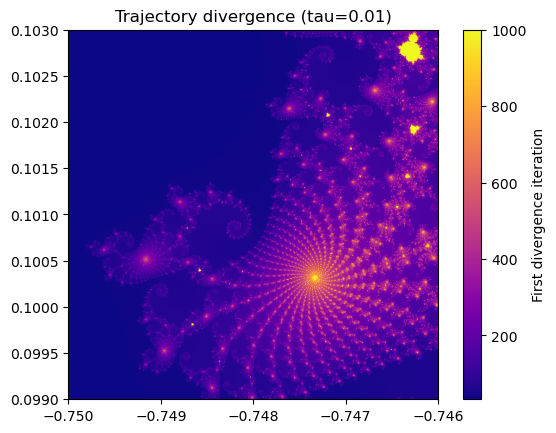

In [29]:
import numpy as np
import matplotlib.pyplot as plt
X_MIN, X_MAX, Y_MIN, Y_MAX = -0.7500, -0.7460, 0.0990, 0.1030
N, MAX_ITER, TAU = 512, 1000, 0.01
x= np.linspace(X_MIN, X_MAX, N)
y= np.linspace(Y_MIN, Y_MAX, N)

C64 = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
z64 = np.zeros_like(C64)
C32 = C64.astype(np.complex64)
z32 = np.zeros_like(C32)

diverge = np.full((N, N), MAX_ITER, dtype=np.int32)
active  = np.ones((N, N), dtype=bool)

for k in range(MAX_ITER):
    if not active.any(): break
    z64[active] = z64[active]**2 + C64[active]
    z32[active] = z32[active]**2 + C32[active]
    diff = np.abs(z32.astype(np.complex128) - z64)
    newly = active & (diff > TAU)
    diverge[newly] = k
    active[newly] = False

plt.imshow(diverge, cmap='plasma', origin='lower', extent=[X_MIN, X_MAX, Y_MIN, Y_MAX])
plt.colorbar(label='First divergence iteration')
plt.title(f'Trajectory divergence (tau={TAU})')
plt.show()

### Mandelbrot Sensitivity Map

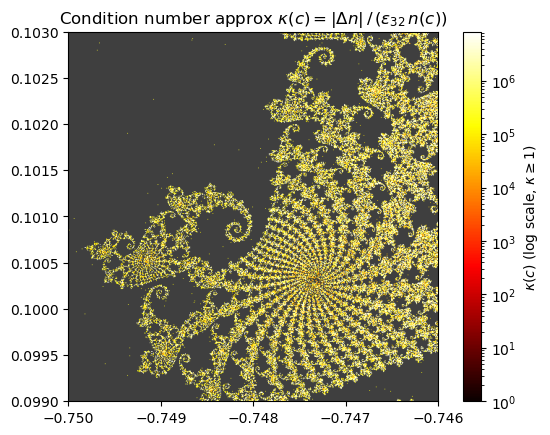

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
N, MAX_ITER = 512, 1000
x = np.linspace(-0.7500, -0.7460, N)
y = np.linspace( 0.0990, 0.1030, N)
C = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
eps32 = float(np.finfo(np.float32).eps)
delta = np.maximum(eps32 * np.abs(C), 1e-10)

def escape_count(C, max_iter):
    z = np.zeros_like(C); cnt = np.full(C.shape, max_iter, dtype=np.int32)
    esc = np.zeros(C.shape, dtype=bool)
    for k in range(max_iter):
        z[~esc] = z[~esc]**2 + C[~esc]
        newly = ~esc & (np.abs(z) > 2.0)
        cnt[newly] = k; esc[newly] = True
    return cnt

n_base = escape_count(C, MAX_ITER).astype(float)
n_perturb = escape_count(C + delta, MAX_ITER).astype(float)
dn = np.abs(n_base - n_perturb)
kappa = np.where(n_base > 0, dn / (eps32 * n_base), np.nan)
cmap_k = plt.cm.hot.copy(); cmap_k.set_bad('0.25')
vmax = np.nanpercentile(kappa, 99)

plt.imshow(kappa, cmap=cmap_k, origin='lower',
           extent=[-0.7500, -0.7460, 0.0990, 0.1030],
           norm=LogNorm(vmin=1, vmax=vmax))
plt.colorbar(label=r'$\kappa(c)$ (log scale, $\kappa \geq 1$)')
plt.title(r'Condition number approx $\kappa(c) = |\Delta n|\,/\,(\varepsilon_{32}\,n(c))$')
plt.show()

#### Brief comment:

The divergence map and sensitivity make are consistent spatially. Regions that diverge quickly (far outside the set) show low sensitivity, and i assume the points well within also show low sensitivity. On the boundaries there is more sensitivity. 

### Testing

``` 
> pytest --cov=. -v test_mandelbrot.py
===================================== test session starts ======================================
platform darwin -- Python 3.11.14, pytest-9.0.2, pluggy-1.6.0 -- /Users/mathias/miniforge3/envs/nsc/bin/python3.11
cachedir: .pytest_cache
rootdir: /Users/mathias/AAU/NSC/mandelbrot-nsc
plugins: anyio-4.12.1, cov-7.0.0
collected 15 items                                                                             

test_mandelbrot.py::test_pixel_all[0j-100-100-mandelbrot_pixel] PASSED                   [  6%]
test_mandelbrot.py::test_pixel_all[0j-100-100-mandelbrot_pixel_numba] PASSED             [ 13%]
test_mandelbrot.py::test_pixel_all[(5+0j)-100-1-mandelbrot_pixel] PASSED                 [ 20%]
test_mandelbrot.py::test_pixel_all[(5+0j)-100-1-mandelbrot_pixel_numba] PASSED           [ 26%]
test_mandelbrot.py::test_pixel_all[(-2.5+0j)-100-1-mandelbrot_pixel] PASSED              [ 33%]
test_mandelbrot.py::test_pixel_all[(-2.5+0j)-100-1-mandelbrot_pixel_numba] PASSED        [ 40%]
test_mandelbrot.py::test_naive_equals_numba PASSED                                       [ 46%]
test_mandelbrot.py::test_mandelbrot_pixel_basic PASSED                                   [ 53%]
test_mandelbrot.py::test_mandelbrot_chunk PASSED                                         [ 60%]
test_mandelbrot.py::test_parallel_equals_serial PASSED                                   [ 66%]
test_mandelbrot.py::test_chunk_sizes PASSED                                              [ 73%]
test_mandelbrot.py::test_dask_equals_serial PASSED                                       [ 80%]
test_mandelbrot.py::test_dask_submit_equals_serial PASSED                                [ 86%]
test_mandelbrot.py::test_dask_chunked PASSED                                             [ 93%]
test_mandelbrot.py::test_cross_validation_small_grid PASSED                              [100%]

======================================== tests coverage ========================================
______________________ coverage: platform darwin, python 3.11.14-final-0 _______________________

Name                                  Stmts   Miss  Cover
---------------------------------------------------------
mandelbrot.py                            77     51    34%
mandelbrot_parallel.py                   97     47    52%
mandelbrot_sensitivity_map.py            27     27     0%
mandelbrot_trajectory_divergence.py      24     24     0%
profiling.py                             10     10     0%
test_mandelbrot.py                       73      0   100%
---------------------------------------------------------
TOTAL                                   308    159    48%
====================================== 15 passed in 7.97s ======================================
```


### Radon

```
> radon cc -s mandelbrot.py
mandelbrot.py
    F 9:0 mandelbrot_naive - A (5)
    F 152:0 mandelbrot_naive_numba - A (5)
    F 194:0 mandelbrot_numba_typed - A (5)
    F 89:0 mandelbrot_point_numba - A (3)
    F 114:0 mandelbrot_hybrid - A (3)
    F 48:0 mandelbrot_numpy - A (2)
> radon cc -s mandelbrot_parallel.py
mandelbrot_parallel.py
    F 172:0 benchmark - A (5)
    F 100:0 mandelbrot_parallel - A (4)
    F 9:0 mandelbrot_pixel - A (3)
    F 35:0 mandelbrot_pixel_numba - A (3)
    F 58:0 mandelbrot_chunk - A (3)
    F 141:0 mandelbrot_dask - A (2)
    F 83:0 mandelbrot_serial - A (1)
    F 94:0 _worker - A (1)
```

In [32]:
import time
def benchmark(func, *args, runs=3):
    """Return median wall time (seconds) over `runs` calls."""
    import statistics
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        func(*args)
        times.append(time.perf_counter() - t0)
    return statistics.median(times)

In [33]:
import numpy as np
import pyopencl as cl
from mandelbrot import mandelbrot_naive, mandelbrot_naive_numba, mandelbrot_numpy, mandelbrot_hybrid, mandelbrot_numba_typed
from mandelbrot_parallel import mandelbrot_parallel, mandelbrot_serial
from mandelbrot_ocl import mandelbrot_gpu

def benchmark_resolutions(ctx, queue, sizes=(1024, 2048, 4096), runs=3):
    all_results = {}

    x_min, x_max = -2.0, 1.0
    y_min, y_max = -1.5, 1.5
    max_iter = 100

    # --- Warmup (important!) ---
    mandelbrot_naive_numba(x_min, x_max, y_min, y_max, 64, 64, max_iter)
    mandelbrot_gpu(ctx, queue, 64, np.float32)

    for N in sizes:
        print(f"\n=== N = {N} ===")

        results = {}

        # Naive
        results["serial"] = benchmark(
            lambda: mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter),
            runs=runs
        )

        # Serial
        results["serial"] = benchmark(
            lambda: mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter),
            runs=runs
        )

        # NumPy
        results["numpy"] = benchmark(
            lambda: mandelbrot_numpy(x_min, x_max, y_min, y_max, N, N, max_iter),
            runs=runs
        )

        # Numba
        results["numba"] = benchmark(
            lambda: mandelbrot_naive_numba(x_min, x_max, y_min, y_max, N, N, max_iter),
            runs=runs
        )

        # Parallel
        results["parallel"] = benchmark(
            lambda: mandelbrot_parallel(N, x_min, x_max, y_min, y_max, max_iter, n_workers=4),
            runs=runs
        )

        # GPU (float32 only on M2)
        results["gpu"] = benchmark(
            lambda: mandelbrot_gpu(ctx, queue, N, np.float32),
            runs=runs
        )

        # Print nicely
        for k, v in results.items():
            print(f"{k:10s}: {v*1e3:.1f} ms")

        all_results[N] = results

    return all_results

ctx = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
results = benchmark_resolutions(ctx, queue, sizes=[1024, 2048, 4096, 8192])


=== N = 1024 ===


KeyboardInterrupt: 

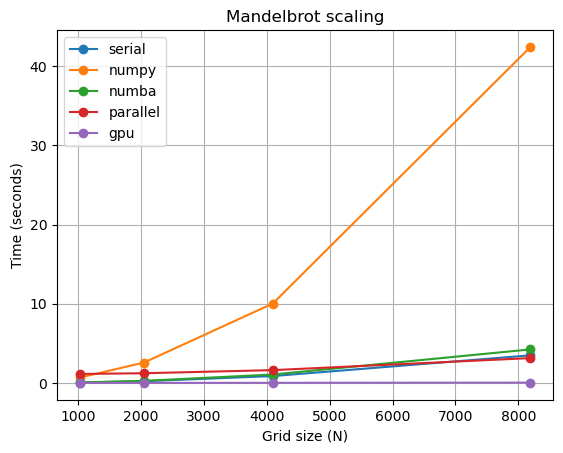

In [ ]:
import matplotlib.pyplot as plt

def plot_scaling(results):
    sizes = sorted(results.keys())
    methods = list(next(iter(results.values())).keys())

    for method in methods:
        times = [results[N][method] for N in sizes]
        plt.plot(sizes, times, marker='o', label=method)

    plt.xlabel("Grid size (N)")
    plt.ylabel("Time (seconds)")
    plt.title("Mandelbrot scaling")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_scaling(results)

| Implementation      | Resolution | Runtime (s) |
|---------------------|------------|-------------|
| Naive Python        | 1024×1024  | 1.8         |
| NumPy vectorised    | 1024×1024  | 0.64        |
| NumPy vectorised    | 2048x2048  | 2.6         |
| NumPy vectorised    | 4096x4096  | 10          |
| NumPy vectorised    | 8192x8192  | 42          |
| Numba f32           | 1024×1024  | 0.16        |
| Numba f32           | 2048x2048  | 0.55        |
| Numba f32           | 4096x4096  | 1.1         |
| Numba f32           | 8192x8192  | 4.2         |
| Numba f64           | 1024×1024  | 0.13        |
| Numba f64           | 2048x2048  | 0.53        |
| Numba f64           | 4096x4096  | 1.1         |
| Numba f64           | 8192x8192  | 4.2         |

Parallel implementations (MP2):
| Implementation      | Resolution | Runtime (s) |
|---------------------|------------|-------------|    
| Parallel            | 1024×1024  | 1.1         |
| Parallel            | 2048x2048  | 1.2         |
| Parallel            | 4096x4096  | 1.6         |
| Parallel            | 8192x8192  | 3.1         |
| Dask Local          | 1024×1024  | 0.059       |
| Dask Local          | 4096x4096  | 0.57        |
| Dask Strato         | 4096x4096  | 0.47        |

GPU implementations (MP3)
| Implementation      | Resolution | Runtime (s) |
|---------------------|------------|-------------|    
| GPU (f32)           | 1024x1024  | 0.0030      |
| GPU (f32)           | 2048x2048  | 0.0074      |
| GPU (f32)           | 4096x4096  | 0.022       |
| GPU (f32)           | 8192x8192  | 0.047       |